In [1]:
# Importing tools
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

# Dataset URLs
delays_url = "https://data.ny.gov/resource/9zbp-wz3y.csv?$limit=50000"
incidents_url = "https://data.ny.gov/resource/g937-7k7c.csv?$limit=50000"
OTP_url = "https://data.ny.gov/resource/f6rf-2a3t.csv?$limit=50000"


In [2]:
# Load datasets
delays = pd.read_csv(delays_url)
incidents = pd.read_csv(incidents_url)
OTP = pd.read_csv(OTP_url)

In [3]:
# Check that the data is from all years, not just 2020
print(delays['month'].unique())
print(incidents['month'].unique())
print(OTP['month'].unique())

['2020-01-01T00:00:00.000' '2020-02-01T00:00:00.000'
 '2020-03-01T00:00:00.000' '2020-04-01T00:00:00.000'
 '2020-05-01T00:00:00.000' '2020-06-01T00:00:00.000'
 '2020-07-01T00:00:00.000' '2020-08-01T00:00:00.000'
 '2020-09-01T00:00:00.000' '2020-10-01T00:00:00.000'
 '2020-11-01T00:00:00.000' '2020-12-01T00:00:00.000'
 '2021-01-01T00:00:00.000' '2021-02-01T00:00:00.000'
 '2021-03-01T00:00:00.000' '2021-04-01T00:00:00.000'
 '2021-05-01T00:00:00.000' '2021-06-01T00:00:00.000'
 '2021-07-01T00:00:00.000' '2021-08-01T00:00:00.000'
 '2021-09-01T00:00:00.000' '2021-10-01T00:00:00.000'
 '2021-11-01T00:00:00.000' '2021-12-01T00:00:00.000'
 '2022-01-01T00:00:00.000' '2022-02-01T00:00:00.000'
 '2022-03-01T00:00:00.000' '2022-04-01T00:00:00.000'
 '2022-05-01T00:00:00.000' '2022-06-01T00:00:00.000'
 '2022-07-01T00:00:00.000' '2022-08-01T00:00:00.000'
 '2022-09-01T00:00:00.000' '2022-10-01T00:00:00.000'
 '2022-11-01T00:00:00.000' '2022-12-01T00:00:00.000'
 '2023-01-01T00:00:00.000' '2023-02-01T00:00:0

In [4]:
# Inspect columns
print(delays.columns)
print(incidents.columns)
print(OTP.columns)

# Convert date columns
delays["month"] = pd.to_datetime(delays["month"])
incidents["month"] = pd.to_datetime(incidents["month"])
OTP["month"] = pd.to_datetime(OTP["month"])

# Check numeric columns
print(delays["month"].info())
print(incidents["month"].info())
print(OTP["month"].info())

Index(['month', 'division', 'line', 'day_type', 'reporting_category',
       'delays'],
      dtype='object')
Index(['month', 'division', 'line', 'day_type', 'reporting_category',
       'incidents'],
      dtype='object')
Index(['month', 'division', 'line', 'day_type', 'num_on_time_trips',
       'num_sched_trips', 'terminal_on_time_performance'],
      dtype='object')
<class 'pandas.core.series.Series'>
RangeIndex: 18592 entries, 0 to 18591
Series name: month
Non-Null Count  Dtype         
--------------  -----         
18592 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 145.4 KB
None
<class 'pandas.core.series.Series'>
RangeIndex: 24332 entries, 0 to 24331
Series name: month
Non-Null Count  Dtype         
--------------  -----         
24332 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 190.2 KB
None
<class 'pandas.core.series.Series'>
RangeIndex: 5092 entries, 0 to 5091
Series name: month
Non-Null Count  Dtype         
--------------  -----    

Notes

* Division - The A Division (numbered subway lines and S 42nd) and B Division (lettered subway lines).

* Line - Each subway line (1, 2, 3, 4, 5, 6, 7, A, C, E, B, D, F, M, G, JZ, L, N, Q, R, S 42nd, S Rock, S Fkln)

* Day Type - Represents weekday as 1 and weekend as 2.

* Infrastructure & Equipment – Delays from the physical subway system itself: signal failures, track defects, subway car mechanical problems, and station/structural issues

* Planned ROW (Right-of-Way) Work – Delays caused by scheduled maintenance or capital construction work performed on the tracks

* Police & Medical – Delays from law-enforcement actions or medical emergencies, including unauthorized people on the tracks and incidents like crime or sick passengers that require a police or medical response

* Crew Availability – Delays caused by a shortage of available train operators/conductors (staffing shortfalls, absences)

* Operating Conditions – Delays tied to how the system is being run in real time, most notably overcrowding

* External Factors – Delays from causes outside MTA's direct control, such as inclement weather

In [5]:
#Cleaning of delays df
delays['Month'] = delays['month'].dt.month_name()
delays['Year'] = delays['month'].dt.year
delays = delays.drop(columns = ['month'])
delays = delays.iloc[:, [5, 6, 0, 1, 2, 3, 4]]
delays.head()

,Month,Year,division,line,day_type,reporting_category,delays
0,January,2020,A DIVISION,1,1,Crew Availability,17
1,January,2020,A DIVISION,1,1,Infrastructure & Equipment,400
2,January,2020,A DIVISION,1,1,Operating Conditions,332
3,January,2020,A DIVISION,1,1,External Factors,314
4,January,2020,A DIVISION,1,1,Police & Medical,345


In [6]:
#Cleaning of incident df
incidents['Month'] = incidents['month'].dt.month_name()
incidents['Year'] = incidents['month'].dt.year
incidents = incidents.drop(columns = ['month'])
incidents = incidents.iloc[:, [5, 6, 0, 1, 2, 3, 4]]
incidents.head()

,Month,Year,division,line,day_type,reporting_category,incidents
0,January,2020,A DIVISION,1,1,NaN,0
1,January,2020,A DIVISION,1,1,Crew Availability,3
2,January,2020,A DIVISION,1,1,External Factors,2
3,January,2020,A DIVISION,1,1,Infrastructure & Equipment,43
4,January,2020,A DIVISION,1,1,Operating Conditions,104


In [7]:
#Cleaning of OTP df
OTP = OTP[(OTP['month'].dt.year >= 2020) & (OTP['month'].dt.year != 2026)]


OTP['Month'] = OTP['month'].dt.month_name()
OTP['Year'] = OTP['month'].dt.year

OTP = OTP.drop(columns = ['month'])

OTP = OTP.iloc[:, [6, 7, 0, 1, 2, 3, 4, 5]]

OTP.head()

,Month,Year,division,line,day_type,num_on_time_trips,num_sched_trips,terminal_on_time_performance
1596,January,2020,A DIVISION,1,1,9035,10554,0.856074
1597,January,2020,A DIVISION,1,2,2866,3050,0.939672
1598,January,2020,A DIVISION,2,1,6058,7330,0.826467
1599,January,2020,A DIVISION,2,2,1674,2340,0.715385
1600,January,2020,A DIVISION,3,1,5732,6603,0.868090


In [8]:
# Merging all of the df together; removing speciality lines
merged_df = pd.merge(delays, incidents, on=['Month', 'Year', 'line', 'reporting_category'], how='inner')
merged_df = pd.merge(merged_df, OTP, on=['Month', 'Year', 'line'], how='inner')

specialty_lines = ['S 42nd', 'S Rock', 'S Fkln', 'JZ']

merged_df = merged_df[~merged_df['line'].isin(specialty_lines)]

merged_df['On Time Performance'] = merged_df['terminal_on_time_performance'].round(2)*100

merged_df = merged_df[['Month', 'Year', 'line', 'reporting_category', 'incidents', 'delays', 'num_on_time_trips', 'num_sched_trips', 'On Time Performance']]

merged_df.head().style.format({
    'incidents': '{:,.0f}',
    'delays': '{:,.0f}',
    'num_on_time_trips': '{:,.0f}',
    'num_sched_trips': '{:,.0f}',
    'On Time Performance': '{:,.0f}%'
})

,Month,Year,line,reporting_category,incidents,delays,num_on_time_trips,num_sched_trips,On Time Performance
0,January,2020,1,Crew Availability,3,17,"9,035","10,554",86%
1,January,2020,1,Crew Availability,3,17,"2,866","3,050",94%
2,January,2020,1,Crew Availability,7,17,"9,035","10,554",86%
3,January,2020,1,Crew Availability,7,17,"2,866","3,050",94%
4,January,2020,1,Infrastructure & Equipment,43,400,"9,035","10,554",86%


In [9]:
# DF that shows which lines are the best/worst in terms of delay rate and OTP
linesummary_df = merged_df.drop(columns = ['Year']).groupby("line", as_index=False).agg({
    'incidents': 'sum',
    'delays': 'sum',
    'On Time Performance' :'mean',
    'num_sched_trips': 'sum'
})

linesummary_df['delay_rate'] = (linesummary_df['delays'] / linesummary_df['num_sched_trips']) * 100

linesummary_df = linesummary_df[['line', 'incidents', 'delays',
                                 'num_sched_trips', 'On Time Performance', 'delay_rate']]

linesummary_df = linesummary_df.sort_values(by=linesummary_df.columns[5],ascending=False)

linesummary_df.head().style.format({
    'incidents': '{:,.0f}',
    'delays': '{:,.0f}',
    'num_sched_trips': '{:,.0f}',
    'On Time Performance': '{:,.0f}%',
    'delay_rate': '{:,.2f}%'
})

,line,incidents,delays,num_sched_trips,On Time Performance,delay_rate
8,B,"11,616","83,913","1,803,629",72%,4.65%
12,F,"115,330","743,580","15,995,768",75%,4.65%
9,C,"64,932","411,888","9,118,846",73%,4.52%
1,2,"124,934","672,336","15,341,308",72%,4.38%
16,N,"123,330","823,696","19,554,666",74%,4.21%


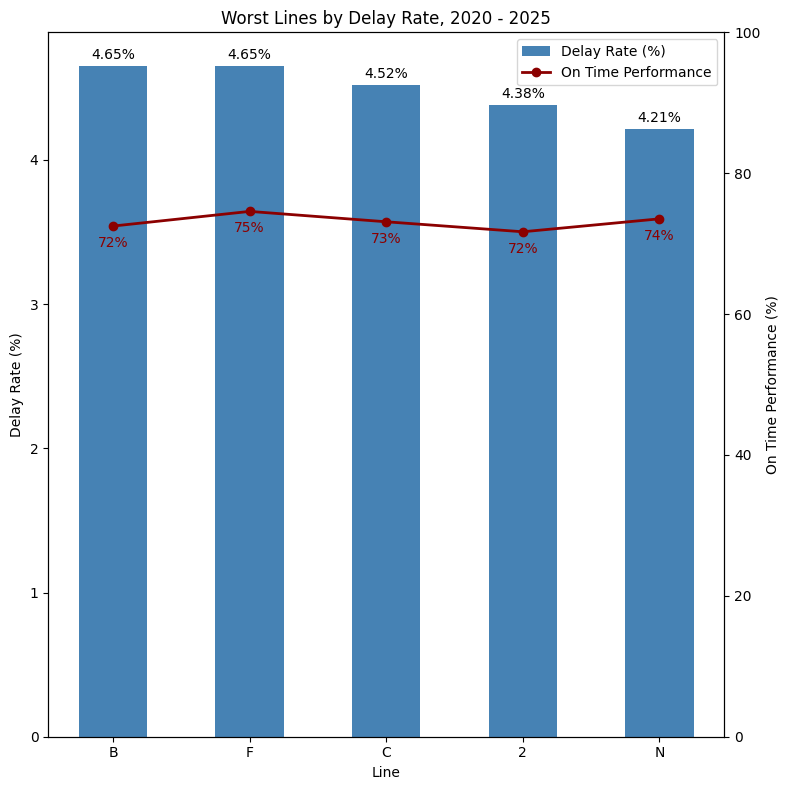

In [10]:
# Rank by delay rate rather than raw delay count
top_5_lines = linesummary_df.nlargest(5, "delay_rate")

x = np.arange(len(top_5_lines))
width = 0.5

fig, ax1 = plt.subplots(figsize=(8, 8))

# Bar graph: delay rate
bars1 = ax1.bar(x, top_5_lines['delay_rate'], width,
                 color='steelblue', label='Delay Rate (%)')

ax1.set_ylabel('Delay Rate (%)')
ax1.set_xlabel('Line')
ax1.set_xticks(x)
ax1.set_xticklabels(top_5_lines['line'])

# Line graph: On Time Performance, on a second y-axis
ax2 = ax1.twinx()
ax2.plot(x, top_5_lines['On Time Performance'],
         color='darkred', marker='o', linewidth=2, label='On Time Performance')
ax2.set_ylabel('On Time Performance (%)')
ax2.set_ylim(0, 100)

plt.title('Worst Lines by Delay Rate, 2020 - 2025')
plt.xticks(rotation=0)

# Bar labels
ax1.bar_label(bars1, labels=[f'{v:.2f}%' for v in top_5_lines['delay_rate']], padding=3)

# Line labels
for xi, y in zip(x, top_5_lines['On Time Performance']):
    ax2.annotate(f'{y:.0f}%', (xi, y), textcoords="offset points", xytext=(0, -15), ha='center', color='darkred')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

In [11]:
# DF that shows which year was the best/worst in terms of delays and OTP
yearsummary_df = merged_df.groupby("Year", as_index=False).agg({
    'incidents': 'sum',
    'delays': 'sum',
    'On Time Performance' :'mean'
})

yearsummary_df = yearsummary_df[['Year', 'incidents', 'delays', 'On Time Performance']]

yearsummary_df = yearsummary_df.sort_values(by=yearsummary_df.columns[2],ascending=False)

yearsummary_df.head(6).style.format({
    'incidents': '{:,.0f}',
    'delays': '{:,.0f}',
    'On Time Performance': '{:,.0f}%'
})

,Year,incidents,delays,On Time Performance
2,2022,"278,749","1,872,094",77%
4,2024,"288,180","1,823,887",79%
3,2023,"274,499","1,689,088",80%
5,2025,"257,894","1,623,799",82%
1,2021,"268,624","1,474,117",82%
0,2020,"199,526","1,007,685",86%


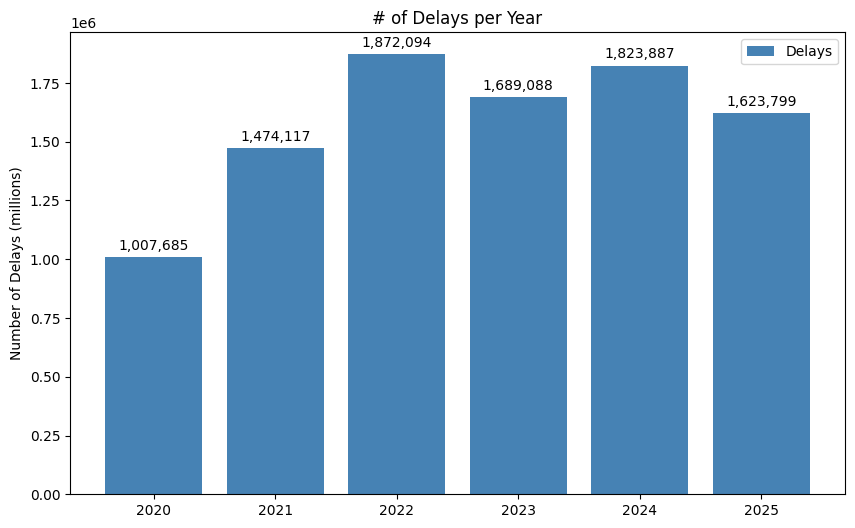

In [12]:
yearsummary_df = yearsummary_df.sort_values(by=yearsummary_df.columns[0],ascending=False)

# Line graph representation of delays over the past 5 years
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(yearsummary_df['Year'], yearsummary_df['delays'],
              color='steelblue', label='Delays')

ax.set_ylabel('Number of Delays (millions)')
ax.set_title('# of Delays per Year')
ax.bar_label(bars, labels=[f'{v:,.0f}' for v in yearsummary_df['delays']], padding=3)

ax.legend()
plt.show()

In [13]:
# DF of the best/worst months (on average) based on delays and OTP
monthsummary_df = merged_df.groupby("Month", as_index=False).agg({
    'incidents': 'sum',
    'delays': 'sum',
    'On Time Performance' :'mean'
})

monthsummary_df = monthsummary_df[['Month', 'incidents', 'delays', 'On Time Performance']]

monthsummary_df = monthsummary_df.sort_values(by=monthsummary_df.columns[2],ascending=False)

monthsummary_df.head(12).style.format({
    'incidents': '{:,.0f}',
    'delays': '{:,.0f}',
    'On Time Performance': '{:,.0f}%'
})

,Month,incidents,delays,On Time Performance
2,December,"141,280","889,087",80%
10,October,"133,939","838,453",81%
5,July,"136,802","830,951",81%
4,January,"133,760","818,008",81%
1,August,"131,101","802,580",82%
3,February,"132,296","800,299",79%
11,September,"124,497","798,438",81%
9,November,"128,437","772,596",82%
6,June,"132,456","767,496",81%
7,March,"131,711","760,430",82%


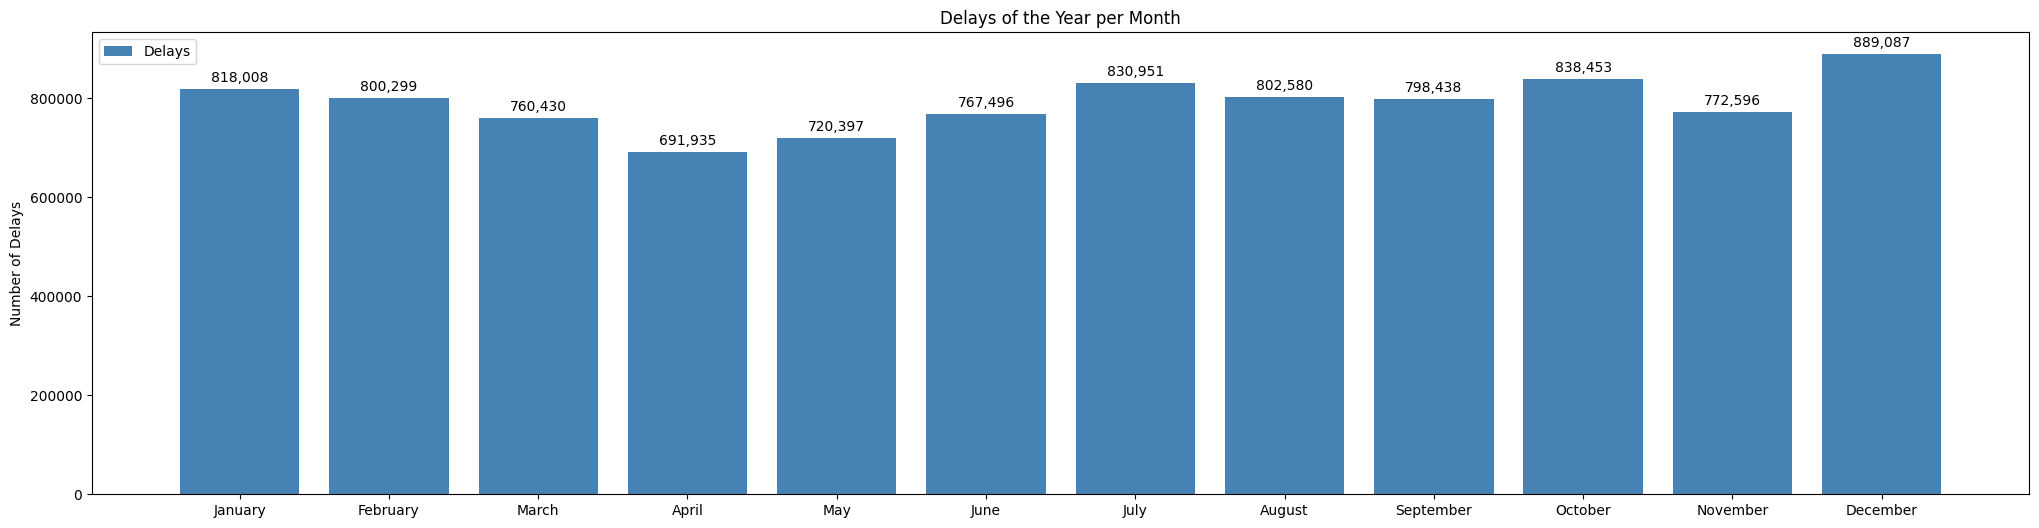

In [14]:
# Bar graph of the months throughout the year
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthsummary_df['Month'] = pd.Categorical(monthsummary_df['Month'], categories=month_order, ordered=True)

monthsummary_df = monthsummary_df.sort_values(by='Month')

fig, ax = plt.subplots(figsize=(25, 6))

bars = ax.bar(monthsummary_df['Month'], monthsummary_df['delays'],
              color='steelblue', label='Delays')

ax.set_ylabel('Number of Delays')
ax.set_title('Delays of the Year per Month')
ax.bar_label(bars, labels=[f'{v:,.0f}' for v in monthsummary_df['delays']], padding=3)

ax.legend()
plt.show()

In [15]:
incident_type_summary_df = merged_df.groupby('reporting_category', as_index=False).agg({
    'incidents': 'sum',
    'delays': 'sum'
})

incident_type_summary_df['Average Delay Per Incident'] = (incident_type_summary_df['delays'] / incident_type_summary_df['incidents']).round(2)

incident_type_summary_df = incident_type_summary_df[['reporting_category', 'incidents', 'delays', 'Average Delay Per Incident']]

incident_type_summary_df = incident_type_summary_df.sort_values(by=incident_type_summary_df.columns[1],ascending=False)

incident_type_summary_df.head(10).style.format({
    'incidents': '{:,.0f}',
    'delays': '{:,.0f}',
    'Average Delay Per Incident': '{:,.2f}',
})

,reporting_category,incidents,delays,Average Delay Per Incident
5,Police & Medical,"386,913","1,936,676",5.01
3,Operating Conditions,"369,168","1,321,775",3.58
2,Infrastructure & Equipment,"319,114","2,676,207",8.39
4,Planned ROW Work,"244,464","1,938,763",7.93
0,Crew Availability,"222,934","1,391,009",6.24
1,External Factors,"24,879","226,240",9.09


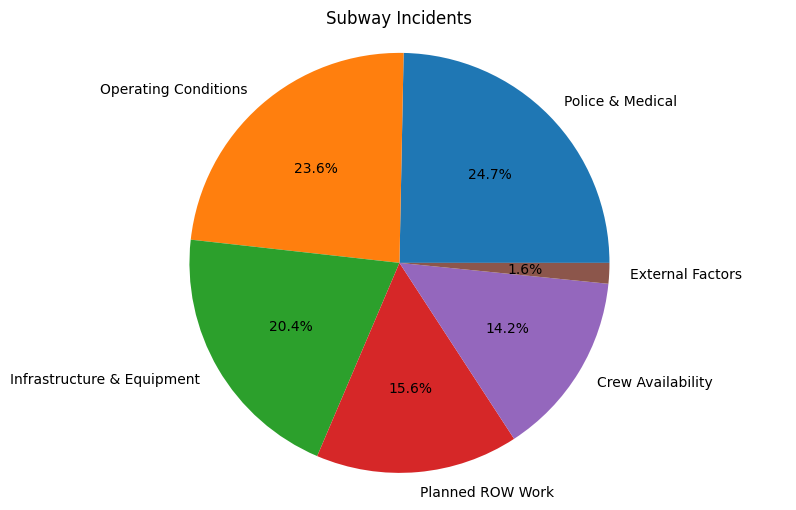

In [16]:
plt.figure(figsize=(10, 6))
plt.pie(
    incident_type_summary_df['incidents'],
    labels=incident_type_summary_df['reporting_category'],
    autopct='%1.1f%%',
    startangle=0,
    colors=plt.cm.tab10.colors
)

plt.title('Subway Incidents')
plt.axis('equal')
plt.show()

In [19]:
linesummary_df.to_csv("linesummary.csv", index=False)
yearsummary_df.to_csv("yearsummary.csv", index=False)
monthsummary_df.to_csv("monthsummary.csv", index=False)
incident_type_summary_df.to_csv("incident_type_summary.csv", index=False)
files.download("linesummary.csv")
files.download("yearsummary.csv")
files.download("monthsummary.csv")
files.download("incident_type_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>